<img src="img/Recurso-26.png" width="200">

## Proyecto Introducción a la Programación en Python - Procesamiento DataSet

![logo](img/python_logo.png)

**Integrantes del grupo:** Sebastian Sampedro, Andrés Aguiar, Santiago Carrasco

## **Introducción al dataset**
El dataset proviene de una fuente pública en Kaggle y contiene listados / precios de propiedades residenciales en venta en diferentes regiones de Estados Unidos (principalmente del noreste y algunas zonas del medio oeste y sur).
Incluye campos como: precio, número de habitaciones, baños, superficie en sqft, código postal (zipcode), dirección completa, ciudad y estado.
No cuenta con fechas de transacción ni con un identificador único de propiedad comparable al EIRCODE irlandés. La granularidad geográfica más fina es el zipcode (5 dígitos) y el estado.

## **Objetivo personal y motivación**
El propósito principal es practicar un flujo completo de limpieza y análisis exploratorio en un dataset inmobiliario real (aunque incompleto y desordenado), con el fin de entender patrones de precios y características por zona geográfica en EE.UU.

Posibles usos futuros de un análisis más avanzado podrían ser:

* 1.- Estimar si un precio de listado está por encima o por debajo del promedio de su zipcode o estado
* 2.- Identificar zonas con mejor relación precio/superficie (precio por sqft bajo)
* 3.- Comparar tipologías de vivienda (por habitaciones y baños) entre estados
* 4.- Servir como base para un modelo simple de valoración comparativa (comps)
* 5.- Entender diferencias estructurales entre mercados urbanos vs rurales / costeros vs interiores

## **Enfoque de este trabajo**
Se busca dejar el dataset con campos principales limpios y útiles:

* Precio numérico
* Habitaciones y baños (enteros)
* Superficie en sqft (entero)
* Zipcode (entero)
* Estado
* Ciudad (extraída cuando posible)
* Precio por pie cuadrado (Price_per_sqft) como métrica clave
* Rango de tamaño aproximado (para análisis comparativos)

## **Pasos aplicados:**

* Normalización y limpieza de columnas con formatos inconsistentes 
* Extracción de componentes de dirección (Street, City, State)
* Eliminación de duplicados
* Imputación de valores faltantes en bedrooms, bathrooms y sqft usando media por zipcode + media global
* Creación de variable derivada: Price_per_sqft
* Análisis visual básico por estado: conteo de propiedades, precio medio por sqft según tamaño, relación precio-superficie

## **Limitaciones importantes:**

No hay fechas → imposible analizar tendencias temporales
No hay indicador de "nueva vs usada"
Muchas direcciones no siguen un formato uniforme → extracción de ciudad/estado no es 100% precisa
El dataset parece tener un sesgo hacia ciertos estados (sobre-representación de algunos códigos postales)

## **Primera impresión y principales hallazgos**

* El dataset limpio queda con ~107k–108k filas útiles (después de eliminar duplicados y limpiar formatos).
* El campo precio está casi siempre presente y limpio después del procesamiento.
* La variable más informativa es Price_per_sqft (precio por pie cuadrado), que permite comparar manzanas de forma más justa que el precio absoluto.
* Hay una enorme dispersión geográfica: algunos estados muestran promedios muy altos (> $300–500/sqft en zonas premium), mientras otros están claramente por debajo de $150 /sqft.
* Las casas de 3 y 4 habitaciones representan la mayoría de la oferta → segmento familiar medio.
* En muchos estados el precio por sqft tiende a ser más alto en propiedades de tamaño mediano (≈1,500–2,500 sqft), posiblemente por ubicaciones más céntricas o con mejor acceso.

## **Recomendaciones rápidas basadas en lo observado**

* Para inversión / alquiler: priorizar estados o zipcodes con Price_per_sqft moderado-bajo + buena cantidad de propiedades de 2–3 habitaciones (posible flujo de renta).
* Para vivienda propia: buscar zonas con relación precio-superficie razonable y oferta amplia de casas familiares (3–4 hab).
- Próximos pasos ideales: enriquecer con
* fechas de listado/venta (aunque sea aproximadas)
* datos externos por zipcode (ingreso medio, tasa de desempleo, escuelas, indice de criminalidad)
* un modelo de regresión o random forest para predecir precio objetivo según sqft, habitaciones, baños, estado y comparables cercanos.


Este ejercicio permitió practicar un pipeline realista de limpieza + EDA en datos inmobiliarios desordenados, aunque la falta de dimensión temporal limita mucho el análisis de tendencias.


### 1. Codigos de Import

In [31]:
import numpy as np
import pandas as pd
import re
from os import path as osp
import seaborn as sns
import matplotlib.pyplot as plt


### 2. Cargamos el dataset

In [26]:
ruta_csv = "ProjectHousing.csv"

properties_dataset = pd.read_csv(
    ruta_csv,
    sep=',',
    header=0,
    engine='python',
    encoding='utf-8'
)

# dibuja la tabla automáticamente
properties_dataset

,Unnamed: 0,Price,Bedroom,Bathroom,sqft,zipcode,Address
0,0,"$289,900",3 Bd,2 Bath,"1,431 Sqft",13084,"1839 Collins Road,\n \n Pompey, N..."
1,1,"$199,900",3 Bd,1 Bath,985 Sqft,13084,"5850 Winacre Drive,\n \n La Fayet..."
2,2,"$114,900",3 Bd,2 Bath,"1,274 Sqft",13084,"3439 Route 11,\n \n La Fayette, N..."
3,3,"$205,092",3 Bd,1 Bath,"1,260 Sqft",13077,"5390 Mead Road,\n \n Homer, NY 13077"
4,4,"$24,900",1 Bd,1 Bath,842 Sqft,13120,"155 Meredith Avenue,\n \n Onondag..."
...,...,...,...,...,...,...,...
107289,107289,"$179,900",4 Bd,2 Bath,"2,052 Sqft",24127,"259 Meadows LN,\n \n New Castle, ..."
107290,107290,"$69,900",3 Bd,2 Bath,"1,440 Sqft",24951,"1546 Wilson Mill Rd,\n \n Lindsid..."
107291,107291,"$244,000",5 Bd,2 Bath,"2,516 Sqft",24970,"176 Ronceverte Ave,\n \n Roncever..."
107292,107292,"$1,150,000",3 Bd,2 Bath,"2,878 Sqft",24962,"106 Creamery Road,\n \n Pence Spr..."


### 3. Inspeccion Inicial

In [5]:
# Inspección básica
print("Forma del dataset:", properties_dataset.shape)
print("\nTipos de datos:\n", properties_dataset.dtypes)
print("\nValores nulos por columna:\n", properties_dataset.isnull().sum())

# Vista previa
display(properties_dataset.head(8))

Forma del dataset: (107294, 7)

Tipos de datos:
 Unnamed: 0     int64
Price         object
Bedroom       object
Bathroom      object
sqft          object
zipcode       object
Address       object
dtype: object

Valores nulos por columna:
 Unnamed: 0        0
Price             0
Bedroom       28742
Bathroom      28742
sqft          28742
zipcode           0
Address           0
dtype: int64


,Unnamed: 0,Price,Bedroom,Bathroom,sqft,zipcode,Address
0,0,"$289,900",3 Bd,2 Bath,"1,431 Sqft",13084,"1839 Collins Road,\n \n Pompey, N..."
1,1,"$199,900",3 Bd,1 Bath,985 Sqft,13084,"5850 Winacre Drive,\n \n La Fayet..."
2,2,"$114,900",3 Bd,2 Bath,"1,274 Sqft",13084,"3439 Route 11,\n \n La Fayette, N..."
3,3,"$205,092",3 Bd,1 Bath,"1,260 Sqft",13077,"5390 Mead Road,\n \n Homer, NY 13077"
4,4,"$24,900",1 Bd,1 Bath,842 Sqft,13120,"155 Meredith Avenue,\n \n Onondag..."
5,5,"$80,000",4 Bd,1 Bath,"1,330 Sqft",13120,"104 West Roswell Avenue,\n \n Ono..."
6,6,"$469,900",NaN,NaN,NaN,13052,"27 S Lake Rd,\n \n De Ruyter, NY ..."
7,7,"$145,000",3 Bd,2 Bath,958 Sqft,13077,"6835 State Route 41,\n \n Scott, ..."


### 4. Limpieza y formateo de columnas principales

In [7]:
# 1. Price → quitar $ y comas → float
properties_dataset['Price'] = (
    properties_dataset['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# 2. Bedroom → extraer número
properties_dataset['Bedroom'] = (
    properties_dataset['Bedroom']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

# 3. Bathroom → extraer número
properties_dataset['Bathroom'] = (
    properties_dataset['Bathroom']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

# 4. sqft → quitar "Sqft", comas y espacios → float
properties_dataset['sqft'] = (
    properties_dataset['sqft']
    .astype(str)
    .str.replace('Sqft', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# 5. zipcode → CORRECCIÓN: Extraer solo números y manejar errores
# Usamos to_numeric con errors='coerce' para que lo que no sea número se vuelva NaN
properties_dataset['zipcode'] = (
    properties_dataset['zipcode']
    .astype(str)
    .str.extract(r'(\d+)', expand=False) # Extrae solo los dígitos
)
properties_dataset['zipcode'] = pd.to_numeric(properties_dataset['zipcode'], errors='coerce')

# 6. Address → limpieza
properties_dataset['Address'] = (
    properties_dataset['Address']
    .astype(str)
    .str.upper()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(', ,', ',', regex=False)
    .str.strip()
)

# MOSTRAR LA TABLA
properties_dataset

,Unnamed: 0,Price,Bedroom,Bathroom,sqft,zipcode,Address
0,0,289900.0,3.0,2.0,1431.0,13084.0,"1839 COLLINS ROAD, POMPEY, NY 13084"
1,1,199900.0,3.0,1.0,985.0,13084.0,"5850 WINACRE DRIVE, LA FAYETTE, NY 13084"
2,2,114900.0,3.0,2.0,1274.0,13084.0,"3439 ROUTE 11, LA FAYETTE, NY 13084"
3,3,205092.0,3.0,1.0,1260.0,13077.0,"5390 MEAD ROAD, HOMER, NY 13077"
4,4,24900.0,1.0,1.0,842.0,13120.0,"155 MEREDITH AVENUE, ONONDAGA INDIAN RESERVATI..."
...,...,...,...,...,...,...,...
107289,107289,179900.0,4.0,2.0,2052.0,24127.0,"259 MEADOWS LN, NEW CASTLE, VA 24127"
107290,107290,69900.0,3.0,2.0,1440.0,24951.0,"1546 WILSON MILL RD, LINDSIDE, WV 24951"
107291,107291,244000.0,5.0,2.0,2516.0,24970.0,"176 RONCEVERTE AVE, RONCEVERTE, WV 24970"
107292,107292,1150000.0,3.0,2.0,2878.0,24962.0,"106 CREAMERY ROAD, PENCE SPRINGS, WV 24962"


### 5. Separar Address en componentes (Street, City, State)

In [8]:
# Separamos la dirección en partes (no todos los registros tienen el mismo formato)
address_parts = properties_dataset['Address'].str.split(',', expand=True, n=2)

properties_dataset['Street'] = address_parts[0].str.strip()

# City suele estar en la segunda posición
properties_dataset['City'] = address_parts[1].str.strip() if address_parts.shape[1] > 1 else pd.NA

# State y posible zip repetido en tercera posición
if address_parts.shape[1] > 2:
    properties_dataset['StateZip'] = address_parts[2].str.strip()
    properties_dataset['State'] = properties_dataset['StateZip'].str.extract(r'([A-Z]{2})')
    properties_dataset = properties_dataset.drop(columns=['StateZip'], errors='ignore')

print("Componentes de dirección extraídos.")
display(properties_dataset[['Address', 'Street', 'City', 'State']].head(10))

Componentes de dirección extraídos.


,Address,Street,City,State
0,"1839 COLLINS ROAD, POMPEY, NY 13084",1839 COLLINS ROAD,POMPEY,NY
1,"5850 WINACRE DRIVE, LA FAYETTE, NY 13084",5850 WINACRE DRIVE,LA FAYETTE,NY
2,"3439 ROUTE 11, LA FAYETTE, NY 13084",3439 ROUTE 11,LA FAYETTE,NY
3,"5390 MEAD ROAD, HOMER, NY 13077",5390 MEAD ROAD,HOMER,NY
4,"155 MEREDITH AVENUE, ONONDAGA INDIAN RESERVATI...",155 MEREDITH AVENUE,ONONDAGA INDIAN RESERVATION,NY
5,"104 WEST ROSWELL AVENUE, ONONDAGA INDIAN RESER...",104 WEST ROSWELL AVENUE,ONONDAGA INDIAN RESERVATION,NY
6,"27 S LAKE RD, DE RUYTER, NY 13052",27 S LAKE RD,DE RUYTER,NY
7,"6835 STATE ROUTE 41, SCOTT, NY 13077",6835 STATE ROUTE 41,SCOTT,NY
8,"151 MATSON AVE E, SYRACUSE, NY 13205",151 MATSON AVE E,SYRACUSE,NY
9,"5625 STATE ROUTE 41, HOMER, NY 13077",5625 STATE ROUTE 41,HOMER,NY


### 6. Eliminacion de duplicados

In [9]:
# Eliminamos filas completamente duplicadas
antes = len(properties_dataset)
properties_dataset = properties_dataset.drop_duplicates()
despues = len(properties_dataset)

print(f"Duplicados eliminados: {antes - despues} filas")
print("Filas actuales:", despues)

Duplicados eliminados: 0 filas
Filas actuales: 107294


### 7. Imputacion de valores faltantes ( Bedroom, Bathroom, sqft)

In [10]:
# Imputamos con la media por zipcode (estrategia más parecida al ejemplo)
for col in ['Bedroom', 'Bathroom', 'sqft']:
    # Media por zipcode
    media_por_zip = properties_dataset.groupby('zipcode')[col].mean()
    
    # Imputamos
    properties_dataset[col] = properties_dataset.apply(
        lambda row: media_por_zip.get(row['zipcode'], np.nan) if pd.isna(row[col]) else row[col],
        axis=1
    )

# Los que aún queden NaN (zipcodes sin datos) → media global
for col in ['Bedroom', 'Bathroom', 'sqft']:
    properties_dataset[col].fillna(properties_dataset[col].mean(), inplace=True)

# Convertimos a enteros (habitaciones y baños suelen ser enteros)
properties_dataset['Bedroom'] = properties_dataset['Bedroom'].round(0).astype(int)
properties_dataset['Bathroom'] = properties_dataset['Bathroom'].round(0).astype(int)
properties_dataset['sqft'] = properties_dataset['sqft'].round(0).astype(int)

print("Valores faltantes imputados.")
print("Nulos restantes:\n", properties_dataset.isnull().sum())

Valores faltantes imputados.
Nulos restantes:
 Unnamed: 0    0
Price         0
Bedroom       0
Bathroom      0
sqft          0
zipcode       6
Address       0
Street        0
City          0
State         0
dtype: int64


/tmp/ipykernel_3143/1464862631.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  properties_dataset[col].fillna(properties_dataset[col].mean(), inplace=True)


### 8. Ingenieria de caracteristicas

In [11]:
# Precio por pie cuadrado (métrica muy útil)
properties_dataset['Price_per_sqft'] = (
    properties_dataset['Price'] / properties_dataset['sqft']
).round(2)

# Opcional: precio por habitación (útil en algunos análisis)
properties_dataset['Price_per_bedroom'] = (
    properties_dataset['Price'] / properties_dataset['Bedroom'].replace(0, 1)
).round(2)

print("Nuevas columnas creadas: Price_per_sqft y Price_per_bedroom")

Nuevas columnas creadas: Price_per_sqft y Price_per_bedroom


### 9. Guardar Version limpia

In [12]:
# Guardamos el resultado
output_path = "ProjectHousing_cleaned.csv"
properties_dataset.to_csv(output_path, index=False, encoding='utf-8')

print(f"Dataset limpio guardado en: {output_path}")
print("Columnas finales:", list(properties_dataset.columns))

Dataset limpio guardado en: ProjectHousing_cleaned.csv
Columnas finales: ['Unnamed: 0', 'Price', 'Bedroom', 'Bathroom', 'sqft', 'zipcode', 'Address', 'Street', 'City', 'State', 'Price_per_sqft', 'Price_per_bedroom']


### 10 Vista final

In [13]:
# Vista rápida del resultado
display(properties_dataset.head(10))

# Estadísticas básicas
display(properties_dataset.describe().round(2))

,Unnamed: 0,Price,Bedroom,Bathroom,sqft,zipcode,Address,Street,City,State,Price_per_sqft,Price_per_bedroom
0,0,289900.0,3,2,1431,13084.0,"1839 COLLINS ROAD, POMPEY, NY 13084",1839 COLLINS ROAD,POMPEY,NY,202.59,96633.33
1,1,199900.0,3,1,985,13084.0,"5850 WINACRE DRIVE, LA FAYETTE, NY 13084",5850 WINACRE DRIVE,LA FAYETTE,NY,202.94,66633.33
2,2,114900.0,3,2,1274,13084.0,"3439 ROUTE 11, LA FAYETTE, NY 13084",3439 ROUTE 11,LA FAYETTE,NY,90.19,38300.00
3,3,205092.0,3,1,1260,13077.0,"5390 MEAD ROAD, HOMER, NY 13077",5390 MEAD ROAD,HOMER,NY,162.77,68364.00
4,4,24900.0,1,1,842,13120.0,"155 MEREDITH AVENUE, ONONDAGA INDIAN RESERVATI...",155 MEREDITH AVENUE,ONONDAGA INDIAN RESERVATION,NY,29.57,24900.00
5,5,80000.0,4,1,1330,13120.0,"104 WEST ROSWELL AVENUE, ONONDAGA INDIAN RESER...",104 WEST ROSWELL AVENUE,ONONDAGA INDIAN RESERVATION,NY,60.15,20000.00
6,6,469900.0,1,1,918,13052.0,"27 S LAKE RD, DE RUYTER, NY 13052",27 S LAKE RD,DE RUYTER,NY,511.87,469900.00
7,7,145000.0,3,2,958,13077.0,"6835 STATE ROUTE 41, SCOTT, NY 13077",6835 STATE ROUTE 41,SCOTT,NY,151.36,48333.33
8,8,79900.0,7,4,2491,13205.0,"151 MATSON AVE E, SYRACUSE, NY 13205",151 MATSON AVE E,SYRACUSE,NY,32.08,11414.29
9,9,257500.0,4,2,2800,13077.0,"5625 STATE ROUTE 41, HOMER, NY 13077",5625 STATE ROUTE 41,HOMER,NY,91.96,64375.00


,Unnamed: 0,Price,Bedroom,Bathroom,sqft,zipcode,Price_per_sqft,Price_per_bedroom
count,107294.00,107294.00,107294.00,107294.00,107294.00,107288.00,107294.00,107294.00
mean,53646.50,437989.62,3.42,2.43,2183.31,18797.15,231.34,125852.95
std,30973.25,649588.48,1.18,1.21,1301.40,3810.46,2507.62,158478.52
min,0.00,0.00,1.00,1.00,1.00,7302.00,0.00,0.00
25%,26823.25,160000.00,3.00,2.00,1456.00,15601.00,95.77,52166.67
50%,53646.50,299900.00,3.00,2.00,1965.00,18431.00,164.40,94975.00
75%,80469.75,499944.25,4.00,3.00,2462.00,21842.00,239.09,149666.46
max,107293.00,30000000.00,49.00,45.00,46656.00,44514.00,224177.20,7500000.00


## Graficos

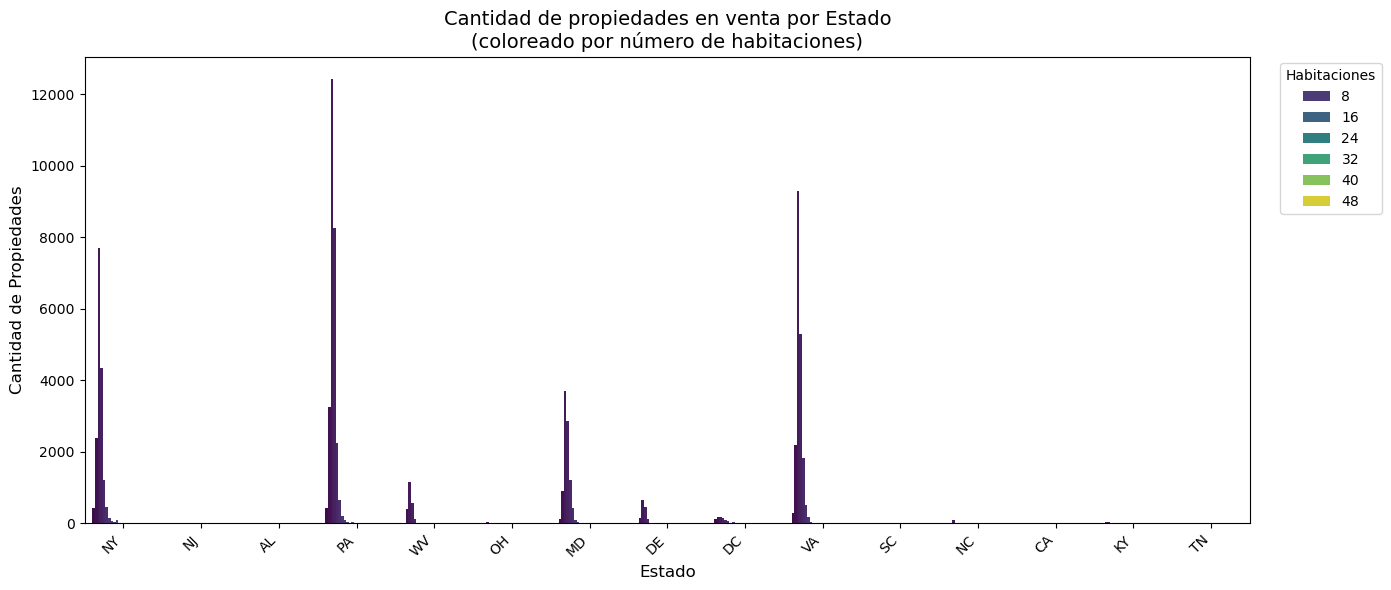

In [33]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extracción del Estado (Indispensable para evitar el KeyError)
# Extraemos las dos letras mayúsculas antes del código postal en la columna 'Address'
properties_dataset['State'] = properties_dataset['Address'].str.extract(r',\s*([A-Z]{2})\s+\d+')

# 2. Limpieza rápida de la columna Bedroom (para que el gráfico funcione bien)
properties_dataset['Bedroom'] = (
    properties_dataset['Bedroom']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

# 3. Configuración del tamaño de la figura
plt.figure(figsize=(14, 6))

# 4. Obtener los 15 estados con más propiedades
top_states = properties_dataset['State'].value_counts().head(15).index
df_top = properties_dataset[properties_dataset['State'].isin(top_states)]

# 5. Creación del gráfico de barras
sns.countplot(
    data=df_top,
    x='State',
    hue='Bedroom',
    palette='viridis',
    hue_order=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
)

# Estética y etiquetas
plt.title("Cantidad de propiedades en venta por Estado\n(coloreado por número de habitaciones)", fontsize=14)
plt.xlabel("Estado", fontsize=12)
plt.ylabel("Cantidad de Propiedades", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Habitaciones", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Descripción: Es la gráfica que muestra la cantidad total de propiedades disponibles en los 15 estados con más anuncios en el dataset.

Qué ves: Barras verticales donde cada color representa el número de habitaciones (1, 2, 3, 4, etc.).

Utilidad: Sirve para comparar el volumen de oferta entre estados; por ejemplo, para ver si un estado tiene muchas más casas de 3 habitaciones en comparación con otros

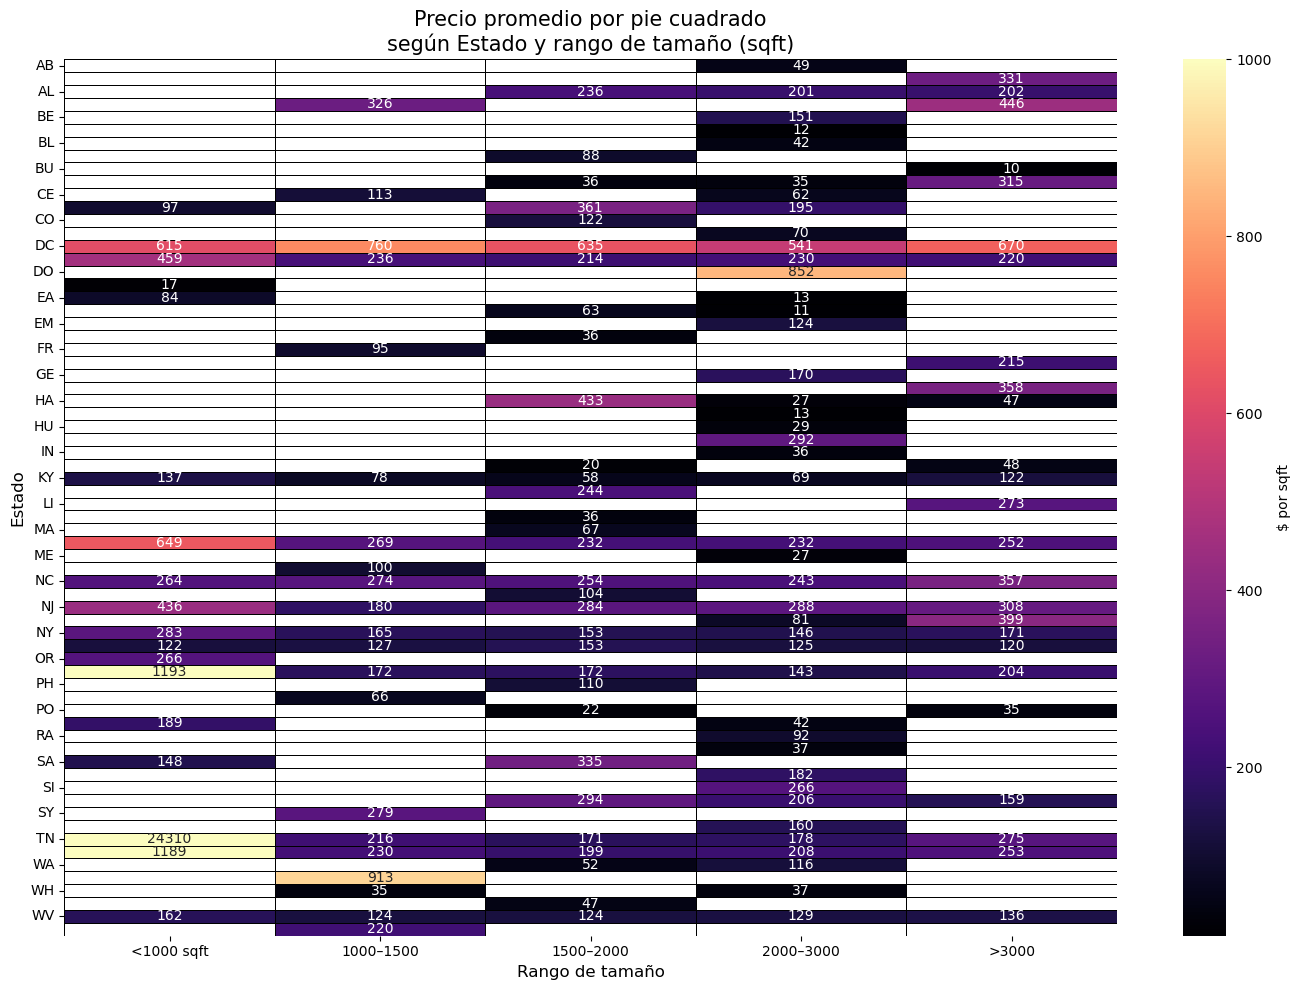

In [18]:
# 1. Calculamos la métrica
properties_dataset['Price_per_sqft'] = properties_dataset['Price'] / properties_dataset['sqft']

# 2. Rangos de sqft
bins = [0, 1000, 1500, 2000, 3000, float('inf')]
labels = ['<1000 sqft', '1000–1500', '1500–2000', '2000–3000', '>3000']
properties_dataset['sqft_range'] = pd.cut(properties_dataset['sqft'], bins=bins, labels=labels, include_lowest=True)

# 3. Pivot Table (Agregamos observed=False para eliminar la advertencia rosa)
pivot = properties_dataset.pivot_table(
    values='Price_per_sqft',
    index='State',
    columns='sqft_range',
    aggfunc='mean',
    observed=False
)

# 4. Heatmap con colores más vibrantes
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot,
    annot=True, 
    fmt=".0f", 
    cmap='magma',        # Colores más intensos (puedes usar 'rocket' o 'viridis' también)
    linewidths=0.5,
    linecolor='black',   # Líneas negras para resaltar los cuadros
    vmax=1000,           # Ajustamos el tope visual para que los colores resalten más
    cbar_kws={'label': '$ por sqft'}
)

plt.title("Precio promedio por pie cuadrado\nsegún Estado y rango de tamaño (sqft)", fontsize=15)
plt.xlabel("Rango de tamaño", fontsize=12)
plt.ylabel("Estado", fontsize=12)
plt.tight_layout()
plt.show()

* Descripción: Una cuadrícula de colores intensos (paleta 'magma') que muestra el precio promedio por pie cuadrado ($/sqft).

* Qué ves: Los Estados están en las filas y los Rangos de tamaño (como <1000 sqft o >3000 sqft) en las columnas. Cada cuadro tiene un número con el precio promedio.

* Utilidad: Identifica de forma visual y rápida las zonas y tamaños de casa donde el metro cuadrado es más costoso (colores más brillantes/naranjas).

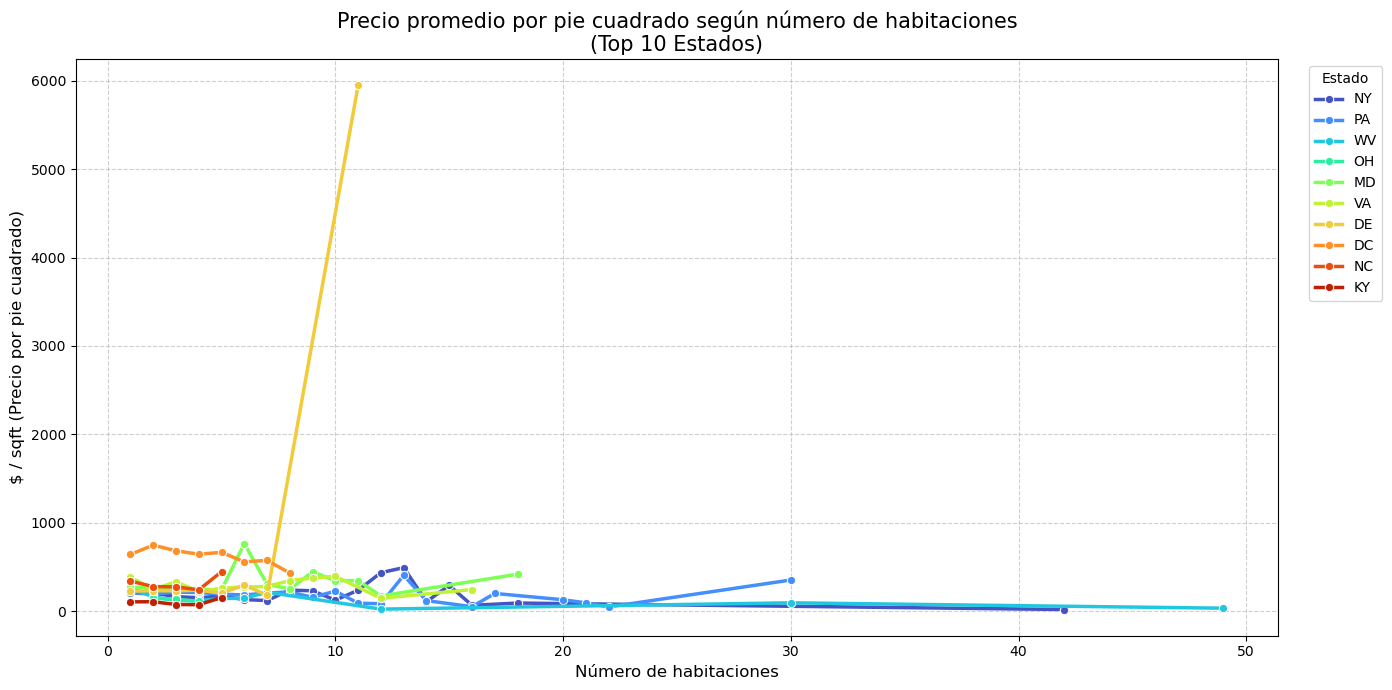

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionar los 10 estados con más propiedades
# CAMBIO: 'df' por 'properties_dataset'
top_states = properties_dataset['State'].value_counts().head(10).index
df_top = properties_dataset[properties_dataset['State'].isin(top_states)]

plt.figure(figsize=(14, 7))

# 2. Crear el gráfico de líneas
sns.lineplot(
    data=df_top,
    x='Bedroom',
    y='Price_per_sqft',
    hue='State',
    marker='o',
    linewidth=2.5,
    palette='turbo',      # Paleta 'turbo' para colores muy vivos y distintos
    errorbar=None         # Esto limpia el gráfico quitando las sombras de error
)

# 3. Estética y títulos
plt.title("Precio promedio por pie cuadrado según número de habitaciones\n(Top 10 Estados)", fontsize=15)
plt.xlabel("Número de habitaciones", fontsize=12)
plt.ylabel("$ / sqft (Precio por pie cuadrado)", fontsize=12)

# Mejoramos la rejilla para que se vea más profesional
plt.grid(True, linestyle='--', alpha=0.6)

# Colocamos la leyenda fuera para que no tape las líneas
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Estado", frameon=True)

plt.tight_layout()
plt.show()

* Descripción: Un gráfico de tendencias que muestra cómo varía el valor del pie cuadrado según el número de habitaciones en los 10 estados principales.

* Qué ves: Varias líneas de colores vibrantes (paleta 'turbo') con puntos marcados. Cada línea representa un Estado diferente.

* Utilidad: Permite ver si el precio por unidad sube o baja conforme la casa es más grande. Por ejemplo, si la línea sube, significa que las casas con más cuartos son más caras por cada pie cuadrado construido.

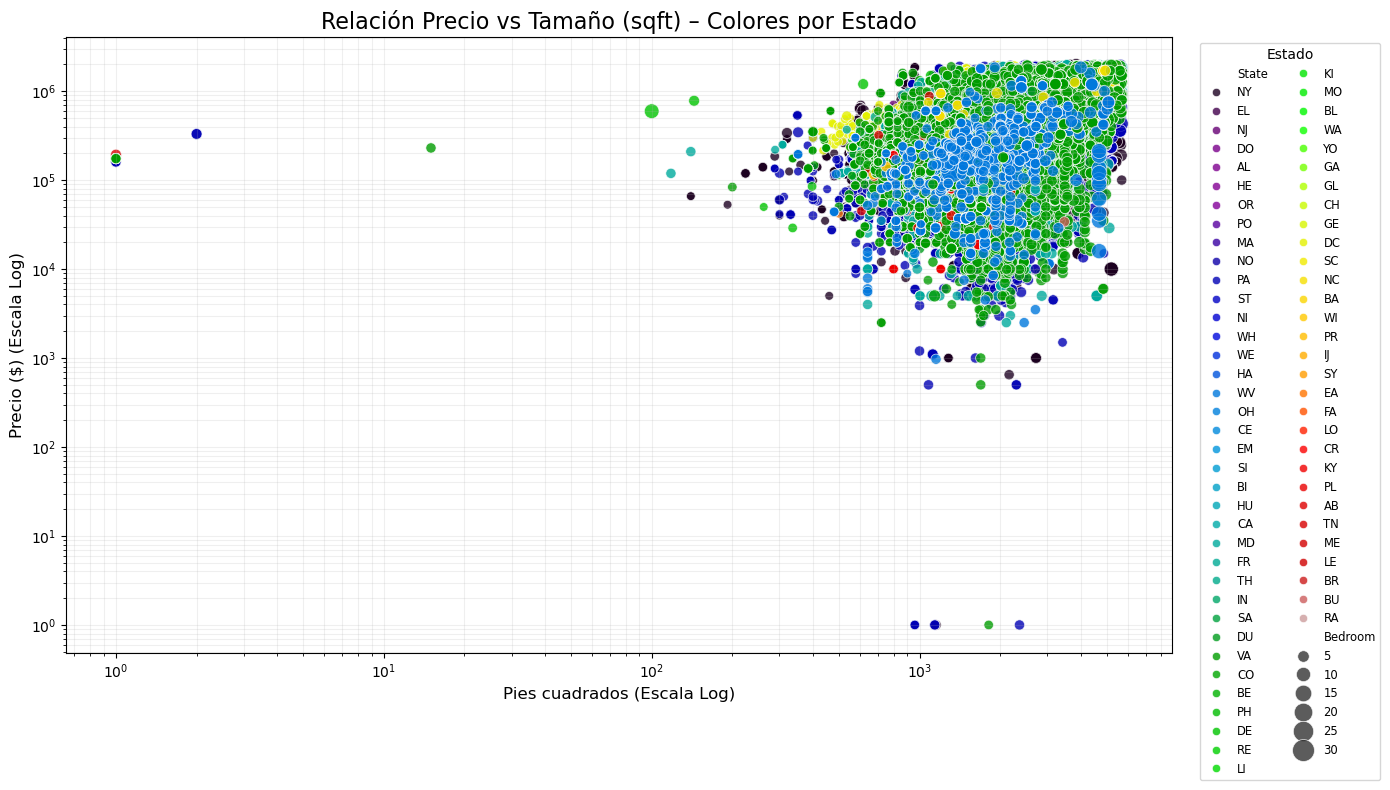

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño de la figura
plt.figure(figsize=(14, 8))

# 1. Filtramos precios extremos usando el nombre correcto: properties_dataset
# Esto ayuda a que el gráfico no se vea aplastado por valores muy altos
df_plot = properties_dataset[
    (properties_dataset['Price'] < properties_dataset['Price'].quantile(0.98)) & 
    (properties_dataset['sqft'] < properties_dataset['sqft'].quantile(0.98))
]

# 2. Creamos el gráfico de dispersión (Scatterplot)
sns.scatterplot(
    data=df_plot,
    x='sqft',
    y='Price',
    hue='State',
    size='Bedroom',
    sizes=(40, 250),     # Aumentamos el tamaño de los puntos para que resalten
    alpha=0.8,           # Menos transparencia para colores más vivos
    palette='nipy_spectral' # Una de las paletas más coloridas y brillantes
)

# 3. Personalización técnica
plt.title("Relación Precio vs Tamaño (sqft) – Colores por Estado", fontsize=16)
plt.xlabel("Pies cuadrados (Escala Log)", fontsize=12)
plt.ylabel("Precio ($) (Escala Log)", fontsize=12)

# Las escalas logarítmicas ayudan a ver mejor la concentración de datos
plt.xscale('log')
plt.yscale('log')

# Leyenda fuera del gráfico para no estorbar
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Estado", ncol=2, fontsize='small')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

* Descripción: Una "nube de puntos" que muestra la relación individual entre el Precio total y el Tamaño (sqft) de cada casa.

* Qué ves: Miles de puntos de muchos colores distribuidos en escalas logarítmicas. El color indica el estado y el tamaño del círculo representa cuántas habitaciones tiene esa propiedad específica.

* Utilidad: Es la imagen más completa para detectar propiedades que son "gangas" (puntos bajos) o de "super lujo" (puntos muy altos), y ver la tendencia general de crecimiento del precio respecto al tamaño.

### Conclusiones
Trabajamos un dataset de propiedades en venta en EE.UU. (precio, habitaciones, baños, sqft, zipcode, ciudad y estado).
La limpieza fue el principal desafío: formatos inconsistentes, direcciones desordenadas y muchos valores faltantes.


Hallazgos clave:

* Gran diferencia de precios entre estados: zonas premium muy caras, otras mucho más accesibles.
* Predominan casas de 3–4 habitaciones (segmento familiar medio).
* Precio por sqft suele ser más alto en propiedades medianas (1,500–2,500 sqft).
* Sin fechas de venta → imposible analizar tendencias temporales o impacto de eventos económicos.
* Concentración en estados con mercados activos y precios elevados (posible sesgo del dataset).

Recomendaciones rápidas:

* Inversión: buscar zonas con alto Price_per_sqft + buena oferta de 2–3 hab.
* Vivienda propia: priorizar estados con precios moderados y buena conectividad.

Fue un ejercicio interesante, pero limitado por la falta de componente temporal.
Próximo paso ideal: enriquecer con fechas y variables externas (ingresos, escuelas, etc.) y entrenar un modelo para estimar valor o potencial de inversión.